In [1]:
!pip -q install numpy pandas matplotlib seaborn scikit-learn tqdm torch torchvision requests pillow

In [2]:
import os
import io
import zipfile
import random
import math
import copy
import json
import time
from collections import deque
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import requests

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

ROOT = Path("mario_pcgrl_project")
ROOT.mkdir(exist_ok=True)
DATA_DIR = ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)



Device: cuda


In [3]:

VGLC_ZIP_URL = "https://github.com/TheVGLC/TheVGLC/archive/refs/heads/master.zip"
zip_path = DATA_DIR / "TheVGLC.zip"

if not zip_path.exists():
    print("Downloading VGLC...")
    r = requests.get(VGLC_ZIP_URL, timeout=60)
    r.raise_for_status()
    zip_path.write_bytes(r.content)
    print("Saved:", zip_path)

extract_dir = DATA_DIR / "TheVGLC"
if not extract_dir.exists():
    print("Extracting...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)

# Find Mario directory automatically
mario_dirs = list(DATA_DIR.rglob("Super Mario Bros"))
print("Mario directories:", mario_dirs[:5])

assert mario_dirs, "Could not find the Super Mario Bros directory in VGLC."
MARIO_DIR = mario_dirs[0]

level_files = sorted(MARIO_DIR.rglob("*.txt"))
print("Number of .txt files:", len(level_files))
print("First files:", level_files[:10])



Saved: mario_pcgrl_project/data/TheVGLC.zip
Extracting...
Mario directories: [PosixPath('mario_pcgrl_project/data/TheVGLC-master/Super Mario Bros')]
Number of .txt files: 58
First files: [PosixPath('mario_pcgrl_project/data/TheVGLC-master/Super Mario Bros/Multi-layer/Height Layer/Height.txt'), PosixPath('mario_pcgrl_project/data/TheVGLC-master/Super Mario Bros/Multi-layer/Player Path Layer/deep_standard_25_Annotated_Path.txt'), PosixPath('mario_pcgrl_project/data/TheVGLC-master/Super Mario Bros/Multi-layer/Player Path Layer/mario-1-1.txt'), PosixPath('mario_pcgrl_project/data/TheVGLC-master/Super Mario Bros/Multi-layer/Player Path Layer/mario-2-1.txt'), PosixPath('mario_pcgrl_project/data/TheVGLC-master/Super Mario Bros/Multi-layer/Player Path Layer/mario-3-1.txt'), PosixPath('mario_pcgrl_project/data/TheVGLC-master/Super Mario Bros/Multi-layer/Player Path Layer/mario-3-2.txt'), PosixPath('mario_pcgrl_project/data/TheVGLC-master/Super Mario Bros/Multi-layer/Player Path Layer/mario-4-1.

In [6]:

def read_level(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.rstrip("\n\r")
            if line:
                rows.append(list(line))
    if not rows:
        return None
    width = max(len(r) for r in rows)
    rows = [r + ["-"] * (width - len(r)) for r in rows]
    return np.array(rows, dtype="<U1")

levels_raw = []
for p in level_files:
    arr = read_level(p)
    if arr is not None:
        levels_raw.append((p.name, arr))

print("Loaded levels:", len(levels_raw))
for name, arr in levels_raw[:5]:
    print(name, arr.shape)


Loaded levels: 58
Height.txt (14, 420)
deep_standard_25_Annotated_Path.txt (14, 206)
mario-1-1.txt (14, 202)
mario-2-1.txt (14, 197)
mario-3-1.txt (14, 197)


In [7]:
from collections import Counter

counter = Counter()
for _, lvl in levels_raw:
    counter.update(lvl.flatten().tolist())

print("Tile vocabulary:")
for k, v in counter.most_common():
    print(repr(k), v)


Tile vocabulary:
'-' 139952
'X' 7202
'x' 6723
'#' 3739
'S' 1864
'1' 1260
'2' 1260
'3' 1260
'4' 1260
'5' 840
'[' 450
']' 450
'B' 422
'o' 396
'E' 378
'p' 178
'P' 178
'<' 170
'>' 170
'?' 167
'Q' 140
'|' 123
'g' 104
'V' 80
'k' 71
'K' 43
'C' 31
'M' 27
'c' 27
'h' 21
'b' 18
't' 16
'O' 12
'+' 10
'd' 8
'D' 8
'*' 8
'Y' 6
'y' 6
'H' 5
'l' 3
'v' 2
'{' 2
'}' 2


In [8]:
WALL_TILES = set(["X", "S", "?", "Q", "<", ">", "[", "]", "B", "b"])
ENEMY_TILES = set(["E", "B", "b"])
# A VGLC '-' is empty/passable. We infer a hole when the cell is empty
# and there is no solid support below it, using a geometry rule.

def semantic_channels(level):
    h, w = level.shape
    walls = np.zeros((h, w), dtype=np.float32)
    enemies = np.zeros((h, w), dtype=np.float32)
    holes = np.zeros((h, w), dtype=np.float32)

    for y in range(h):
        for x in range(w):
            t = level[y, x]
            if t in WALL_TILES:
                walls[y, x] = 1.0
            if t in ENEMY_TILES:
                enemies[y, x] = 1.0

    # Infer holes from unsupported empty cells near the gameplay floor.
    # This is a self-contained approximation, because VGLC does not use
    # the paper's exact internal "hole tile" representation.
    for x in range(w):
        support_exists = False
        for y in range(h - 1, -1, -1):
            if walls[y, x] == 1:
                support_exists = True
            elif level[y, x] == "-" and not support_exists and y >= h - 5:
                holes[y, x] = 1.0

    return np.stack([walls, enemies, holes], axis=0)

# The VGLC representation is generally 16 rows. The paper uses 15 rows.
# We remove the topmost row to obtain a 15-row gameplay grid.
def to_15xw(level):
    if level.shape[0] >= 15:
        return level[-15:, :]
    pad = np.full((15-level.shape[0], level.shape[1]), "-", dtype="<U1")
    return np.vstack([pad, level])

semantic_levels = []
for name, lvl in levels_raw:
    lvl15 = to_15xw(lvl)
    semantic_levels.append((name, semantic_channels(lvl15), lvl15))

print("Prepared:", len(semantic_levels))
print("Example shape:", semantic_levels[0][1].shape)

Prepared: 58
Example shape: (3, 15, 420)


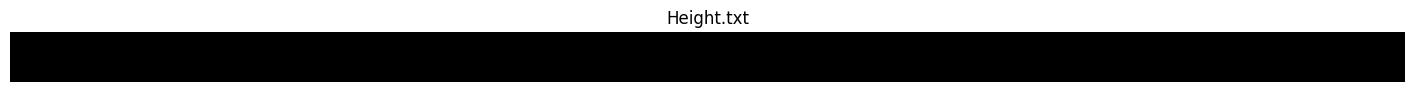

In [9]:

def plot_semantic(ch, title="Semantic level"):
    # RGB-like visualization: wall=red, enemy=green, hole=blue
    img = np.transpose(ch, (1, 2, 0))
    plt.figure(figsize=(18, 5))
    plt.imshow(img, interpolation="nearest")
    plt.title(title)
    plt.axis("off")
    plt.show()

plot_semantic(semantic_levels[0][1], semantic_levels[0][0])



In [11]:
# Cell 9 — Extract 15×4 patterns with sliding window

PATTERN_H = 15
PATTERN_W = 4

patterns = []
pattern_contexts = []

for name, ch, _ in semantic_levels:
    # ch shape = (3, 15, width)
    channels, h, w = ch.shape

    if channels != 3 or h != PATTERN_H or w < PATTERN_W:
        continue

    # Slide the 4-column window across the level width
    for x in range(w - PATTERN_W + 1):

        # Correct slicing:
        # channels = all 3
        # height   = all 15 rows
        # width    = 4 columns
        p = ch[:, :, x:x + PATTERN_W]

        # Expected shape = (3, 15, 4)
        assert p.shape == (3, PATTERN_H, PATTERN_W)

        patterns.append(p.astype(np.float32))
        pattern_contexts.append((name, x))

# Stack all patterns
if patterns:
    patterns = np.stack(patterns, axis=0)
else:
    patterns = np.empty(
        (0, 3, PATTERN_H, PATTERN_W),
        dtype=np.float32
    )

print("Extracted patterns:", len(patterns))
print("Pattern tensor shape:", patterns.shape)

Extracted patterns: 11904
Pattern tensor shape: (11904, 3, 15, 4)


In [12]:
patterns_u8 = (patterns > 0.5).astype(np.uint8)

# unique over flattened pattern
flat = patterns_u8.reshape(len(patterns_u8), -1)
unique_flat, unique_idx = np.unique(flat, axis=0, return_index=True)
legal_patterns = unique_flat.reshape(-1, 3, 15, 4).astype(np.float32)

print("Unique legal patterns:", len(legal_patterns))

Unique legal patterns: 2689


In [13]:

class PatternDataset(Dataset):
    def __init__(self, patterns):
        self.patterns = torch.tensor(patterns, dtype=torch.float32)

    def __len__(self):
        return len(self.patterns)

    def __getitem__(self, idx):
        return self.patterns[idx]

# To make the notebook practical, cap the training bank if VGLC is very large.
MAX_PATTERNS = min(len(legal_patterns), 12000)
rng = np.random.default_rng(SEED)
subset_idx = rng.choice(len(legal_patterns), MAX_PATTERNS, replace=False)
train_patterns = legal_patterns[subset_idx]

pattern_loader = DataLoader(
    PatternDataset(train_patterns),
    batch_size=64,
    shuffle=True,
    drop_last=True
)

print("CGAN training patterns:", len(train_patterns))



CGAN training patterns: 2689


In [14]:
class PatternGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        # 9 channels = three previous 3-channel patterns
        self.cond = nn.Sequential(
            nn.Conv2d(9, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
        )

        self.z = nn.Sequential(
            nn.Linear(3, 64 * 15 * 4),
            nn.ReLU()
        )

        self.head = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 3, 1),
            nn.Sigmoid()
        )

    def forward(self, z, prev3):
        c = self.cond(prev3)
        zf = self.z(z).view(z.size(0), 64, 15, 4)
        return self.head(torch.cat([c, zf], dim=1))


class PatternDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(12, 64, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128 * 15 * 4, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, pattern, prev3):
        return self.net(torch.cat([pattern, prev3], dim=1))

G = PatternGenerator().to(DEVICE)
D = PatternDiscriminator().to(DEVICE)

print("Generator parameters:", sum(p.numel() for p in G.parameters()))
print("Discriminator parameters:", sum(p.numel() for p in D.parameters()))

Generator parameters: 128835
Discriminator parameters: 1064129


In [15]:
sequences = []

for name, ch, _ in semantic_levels:
    _, h, w = ch.shape
    if w < 4:
        continue
    seq = [ch[:, :, x:x+4].astype(np.float32) for x in range(w-3)]
    if len(seq) >= 4:
        sequences.append(seq)

print("Sequences:", len(sequences))

# Build training tuples.
cond_list = []
target_list = []

for seq in sequences:
    # First target uses zero context; later targets use actual history.
    for i in range(3, len(seq)):
        prev = np.concatenate([seq[i-3], seq[i-2], seq[i-1]], axis=0)
        cond_list.append(prev)
        target_list.append(seq[i])

# Cap for practical training.
MAX_CGAN_TUPLES = min(len(target_list), 20000)
idx = rng.choice(len(target_list), MAX_CGAN_TUPLES, replace=False)

cond_arr = np.stack(cond_list)[idx]
target_arr = np.stack(target_list)[idx]

class CGANDataset(Dataset):
    def __init__(self, cond, target):
        self.cond = torch.tensor(cond, dtype=torch.float32)
        self.target = torch.tensor(target, dtype=torch.float32)
    def __len__(self):
        return len(self.target)
    def __getitem__(self, i):
        return self.cond[i], self.target[i]

cgan_loader = DataLoader(
    CGANDataset(cond_arr, target_arr),
    batch_size=64,
    shuffle=True,
    drop_last=True
)

print("CGAN tuples:", len(target_arr))



Sequences: 58
CGAN tuples: 11730


CGAN 1/10:   0%|          | 0/183 [00:00<?, ?it/s]

Epoch 1: G=3.7225, D=0.7488


CGAN 2/10:   0%|          | 0/183 [00:00<?, ?it/s]

Epoch 2: G=1.7572, D=1.1311


CGAN 3/10:   0%|          | 0/183 [00:00<?, ?it/s]

...

Epoch 8: G=1.2082, D=1.1883


CGAN 9/10:   0%|          | 0/183 [00:00<?, ?it/s]

Epoch 9: G=1.2034, D=1.1732


CGAN 10/10:   0%|          | 0/183 [00:00<?, ?it/s]

Epoch 10: G=1.2562, D=1.1826


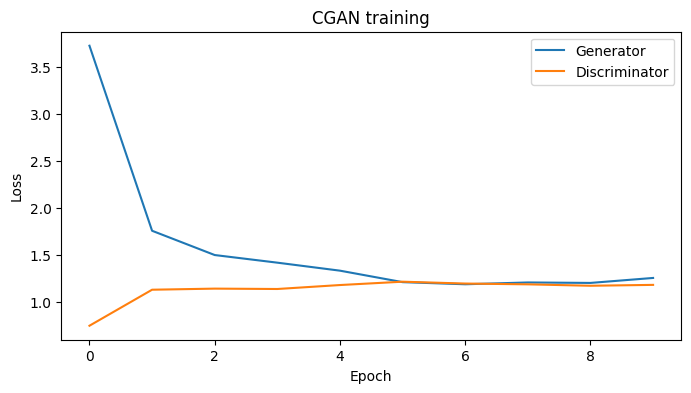

In [16]:

def train_cgan(epochs=10, lr=2e-4):
    optG = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    optD = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()

    history = []

    for epoch in range(epochs):
        g_total = 0.0
        d_total = 0.0

        for cond, real in tqdm(cgan_loader, desc=f"CGAN {epoch+1}/{epochs}", leave=False):
            cond = cond.to(DEVICE)
            real = real.to(DEVICE)

            z = torch.rand(real.size(0), 3, device=DEVICE)

            # ---- Discriminator ----
            fake = G(z, cond).detach()
            real_logits = D(real, cond)
            fake_logits = D(fake, cond)

            d_loss = (
                bce(real_logits, torch.ones_like(real_logits)) +
                bce(fake_logits, torch.zeros_like(fake_logits))
            )

            optD.zero_grad()
            d_loss.backward()
            optD.step()

            # ---- Generator ----
            z = torch.rand(real.size(0), 3, device=DEVICE)
            fake = G(z, cond)
            fake_logits = D(fake, cond)

            # GAN loss + reconstruction loss.
            # The reconstruction term stabilizes training for a small level dataset.
            g_loss = bce(fake_logits, torch.ones_like(fake_logits)) + 10.0 * F.binary_cross_entropy(fake, real)

            optG.zero_grad()
            g_loss.backward()
            optG.step()

            g_total += g_loss.item()
            d_total += d_loss.item()

        history.append((g_total / len(cgan_loader), d_total / len(cgan_loader)))
        print(f"Epoch {epoch+1}: G={history[-1][0]:.4f}, D={history[-1][1]:.4f}")

    return history

CGAN_EPOCHS = 10
cgan_history = train_cgan(CGAN_EPOCHS)

plt.figure(figsize=(8,4))
plt.plot([x[0] for x in cgan_history], label="Generator")
plt.plot([x[1] for x in cgan_history], label="Discriminator")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("CGAN training")
plt.show()


In [17]:

LEGAL = torch.tensor(train_patterns, dtype=torch.float32, device=DEVICE)
LEGAL_FLAT = LEGAL.flatten(start_dim=1)

@torch.no_grad()
def match_pattern(candidate):
    c = candidate.flatten().to(DEVICE)
    distances = torch.mean((LEGAL_FLAT - c.unsqueeze(0)) ** 2, dim=1)
    idx = torch.argmin(distances)
    return LEGAL[idx].detach().cpu().numpy(), float(distances[idx].item())

@torch.no_grad()
def cgan_generate(action, prev_patterns):
    # prev_patterns = list of 3 arrays, each (3,15,4)
    cond = np.concatenate(prev_patterns, axis=0)
    cond = torch.tensor(cond, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    z = torch.tensor(action, dtype=torch.float32, device=DEVICE).view(1,3)
    out = G(z, cond)[0]
    matched, dist = match_pattern(out)
    return matched, dist

# quick test
zero_pat = np.zeros((3,15,4), dtype=np.float32)
candidate, distance = cgan_generate([0.2,0.5,0.8], [zero_pat, zero_pat, zero_pat])
print(candidate.shape, distance)


(3, 15, 4) 2.425654486160056e-07


In [18]:

def concat_patterns(pattern_list):
    return np.concatenate(pattern_list, axis=2)

def wall_hole_signature(pattern):
    # Paper's monotony comparison focuses on wall/hole placement.
    return np.concatenate([pattern[0:1], pattern[2:3]], axis=0)

def same_wall_hole(a, b):
    return int(np.array_equal(wall_hole_signature(a), wall_hole_signature(b)))

def monotony_reward(patterns, current_idx):
    if current_idx == 0:
        return 1.0

    weights = [8/15, 4/15, 2/15, 1/15]
    penalty = 0.0

    for k, w in enumerate(weights, start=1):
        j = current_idx - k
        if j >= 0:
            penalty += w * same_wall_hole(patterns[current_idx], patterns[j])

    return float(np.clip(1.0 - penalty, 0.0, 1.0))


def level_grid(level_patterns):
    return concat_patterns(level_patterns)


def playable_grid(level):
    # Lightweight reachability:
    # Mario starts near the bottom-left. A state is (x,y).
    # We allow left/right/up/down movement, but require landing on
    # non-hole cells. This is a conservative proxy, not a full Mario physics model.

    wall = level[0]
    enemy = level[1]
    hole = level[2]
    h, w = wall.shape

    # Find a starting cell in lower quarter.
    starts = []
    for y in range(max(0,h-5), h):
        if wall[y, 0] == 0 and hole[y,0] == 0:
            starts.append((y,0))

    if not starts:
        return False

    q = deque(starts)
    visited = set(starts)

    while q:
        y,x = q.popleft()

        # Reaching the final few columns means the level is traversable.
        if x >= w-2:
            return True

        # Basic movement plus one-tile jump-like vertical movement.
        candidates = [
            (y, x+1), (y, x+2),
            (y-1, x+1), (y-2, x+1),
            (y+1, x+1),
            (y, x-1)
        ]

        for ny,nx in candidates:
            if not (0 <= ny < h and 0 <= nx < w):
                continue
            if wall[ny,nx] == 1 or hole[ny,nx] == 1:
                continue
            state = (ny,nx)
            if state not in visited:
                visited.add(state)
                q.append(state)

    return False


def difficulty_trial(level, rng):
    wall, enemy, hole = level
    h, w = wall.shape

    # Find an approximate floor trajectory.
    y = h - 2
    enemy_damage = 0
    hole_damage = 0

    # Human-like stochasticity:
    # 30% chance of delayed/early action and 30% chance of a two-frame repeat.
    timing_noise = rng.random(w) < 0.30
    long_press = rng.random(w) < 0.30

    for x in range(w):
        if timing_noise[x]:
            # Timing error increases risk around hazards.
            for yy in range(max(0,y-2), min(h,y+3)):
                if enemy[yy,x] == 1:
                    enemy_damage += 1
                if hole[yy,x] == 1:
                    hole_damage += 1

        if long_press[x] and x+1 < w:
            if enemy[:,x:x+2].sum() > 0:
                enemy_damage += 1
            if hole[:,x:x+2].sum() > 0:
                hole_damage += 1

        # Choose a nearby safe y position for next step.
        candidates = [y, max(0,y-1), max(0,y-2), min(h-1,y+1)]
        safe = [yy for yy in candidates if wall[yy,x] == 0 and hole[yy,x] == 0]
        if safe:
            y = safe[rng.integers(len(safe))]
        else:
            hole_damage += 1

        # Direct enemy exposure.
        if enemy[max(0,y-1):min(h,y+2), x].sum() > 0:
            enemy_damage += 1

    return enemy_damage, hole_damage


def difficulty_score(level, trials=8, seed=0):
    rng = np.random.default_rng(seed)
    damages = []

    for _ in range(trials):
        e, h = difficulty_trial(level, rng)
        damages.append(e + 1.1*h)

    totaldmg = float(np.mean(damages))

    # Smooth approximation of the paper's bell/triangular appropriateness curve.
    # Best score is around a moderate damage range rather than at zero.
    target = 8.0
    scale = 8.0
    rdiff = float(np.exp(-((totaldmg-target)**2)/(2*scale**2)))

    return rdiff, totaldmg, float(np.std(damages))


def evaluate_level(level_patterns, difficulty_trials=8, seed=0):
    level = level_grid(level_patterns)

    playable = playable_grid(level)

    if not playable:
        return {
            "playable": 0,
            "rdiff": 0.0,
            "rmono": 0.0,
            "total_reward": 0.0,
            "totaldmg": float("inf"),
            "damage_std": 0.0
        }

    mono_vals = [monotony_reward(level_patterns, i) for i in range(len(level_patterns))]
    rmono = float(np.mean(mono_vals))

    rdiff, dmg, dmg_std = difficulty_score(level, difficulty_trials, seed)
    total_reward = float(rdiff + 0.01 * sum(mono_vals))

    return {
        "playable": 1,
        "rdiff": rdiff,
        "rmono": rmono,
        "total_reward": total_reward,
        "totaldmg": dmg,
        "damage_std": dmg_std
    }


In [19]:

def random_initial_patterns(c=2, seed=None):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(train_patterns), c, replace=False)
    return [train_patterns[i].copy() for i in idx]


def generate_level_random(num_patterns=10, seed=None):
    rng = np.random.default_rng(seed)
    return [train_patterns[i].copy() for i in rng.choice(len(train_patterns), num_patterns, replace=False)]


test_level = generate_level_random(10, 1)
print(evaluate_level(test_level, difficulty_trials=5, seed=1))



{'playable': 1, 'rdiff': 0.5777418565715644, 'rmono': 1.0, 'total_reward': 0.6777418565715644, 'totaldmg': 16.380000000000003, 'damage_std': 6.732428982172778}


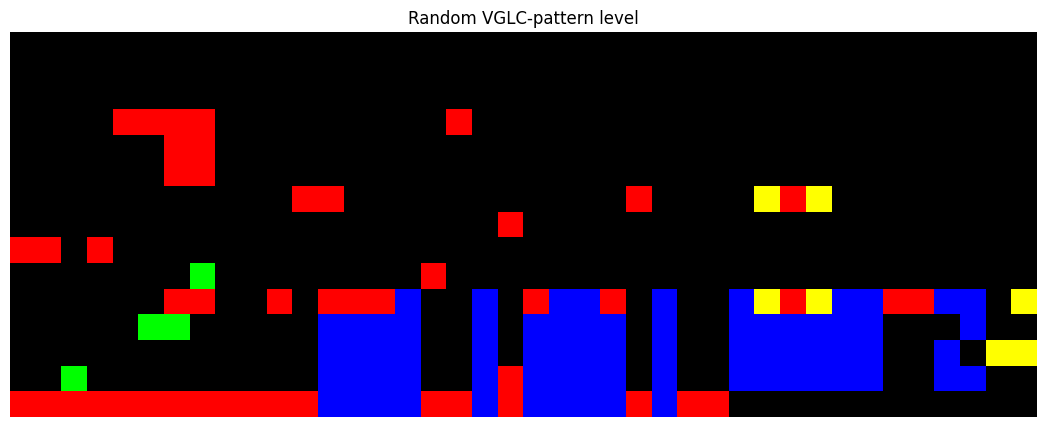

In [20]:

def show_level(patterns, title="Generated level", figsize=(18,5)):
    level = level_grid(patterns)
    img = np.transpose(level, (1,2,0))
    plt.figure(figsize=figsize)
    plt.imshow(img, interpolation="nearest")
    plt.title(title)
    plt.axis("off")
    plt.show()

show_level(test_level, "Random VGLC-pattern level")



In [21]:

class Actor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 3 * 10, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 3),
            nn.Sigmoid()
        )

    def forward(self, state):
        return self.fc(self.features(state))


class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.state_net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
        )
        self.q = nn.Sequential(
            nn.Linear(64 * 3 * 10 + 3, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, state, action):
        s = self.state_net(state)
        return self.q(torch.cat([s, action], dim=1))


actor = Actor().to(DEVICE)
actor_target = copy.deepcopy(actor).to(DEVICE)
critic1 = Critic().to(DEVICE)
critic2 = Critic().to(DEVICE)
critic1_target = copy.deepcopy(critic1).to(DEVICE)
critic2_target = copy.deepcopy(critic2).to(DEVICE)

print("Actor:", sum(p.numel() for p in actor.parameters()))
print("Critic:", sum(p.numel() for p in critic1.parameters()))






Actor: 590627
Critic: 544961


In [22]:
class ReplayBuffer:
    def __init__(self, capacity=40000):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((
            state.astype(np.float32),
            action.astype(np.float32),
            np.float32(reward),
            next_state.astype(np.float32),
            np.float32(done)
        ))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s,a,r,ns,d = zip(*batch)
        return (
            torch.tensor(np.stack(s), dtype=torch.float32, device=DEVICE),
            torch.tensor(np.stack(a), dtype=torch.float32, device=DEVICE),
            torch.tensor(np.array(r), dtype=torch.float32, device=DEVICE).unsqueeze(1),
            torch.tensor(np.stack(ns), dtype=torch.float32, device=DEVICE),
            torch.tensor(np.array(d), dtype=torch.float32, device=DEVICE).unsqueeze(1),
        )

    def __len__(self):
        return len(self.buffer)


class TD3Agent:
    def __init__(self):
        self.actor = actor
        self.actor_target = actor_target
        self.critic1 = critic1
        self.critic2 = critic2
        self.critic1_target = critic1_target
        self.critic2_target = critic2_target

        # Paper values are 5e-6 / 5e-5.
        # We use slightly larger actor LR by default for practical small-scale learning.
        self.actor_opt = torch.optim.Adam(self.actor.parameters(), lr=5e-5)
        self.critic1_opt = torch.optim.Adam(self.critic1.parameters(), lr=5e-4)
        self.critic2_opt = torch.optim.Adam(self.critic2.parameters(), lr=5e-4)

        self.gamma = 0.99
        self.tau = 0.005
        self.policy_noise = 0.15
        self.noise_clip = 0.30
        self.policy_delay = 2

        self.total_updates = 0

    @torch.no_grad()
    def act(self, state, noise_std=0.1):
        s = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        a = self.actor(s)[0].cpu().numpy()
        if noise_std > 0:
            a += np.random.normal(0, noise_std, size=3)
        return np.clip(a, 0.0, 1.0).astype(np.float32)

    def train_step(self, replay, batch_size=32):
        if len(replay) < batch_size:
            return None

        s,a,r,ns,d = replay.sample(batch_size)

        with torch.no_grad():
            noise = (torch.randn_like(a) * self.policy_noise).clamp(
                -self.noise_clip, self.noise_clip
            )
            next_a = (self.actor_target(ns) + noise).clamp(0,1)

            tq1 = self.critic1_target(ns, next_a)
            tq2 = self.critic2_target(ns, next_a)
            target_q = r + (1-d) * self.gamma * torch.min(tq1, tq2)

        q1 = self.critic1(s,a)
        q2 = self.critic2(s,a)

        c1_loss = F.mse_loss(q1, target_q)
        c2_loss = F.mse_loss(q2, target_q)

        self.critic1_opt.zero_grad()
        c1_loss.backward()
        self.critic1_opt.step()

        self.critic2_opt.zero_grad()
        c2_loss.backward()
        self.critic2_opt.step()

        self.total_updates += 1

        if self.total_updates % self.policy_delay == 0:
            actor_loss = -self.critic1(s, self.actor(s)).mean()

            self.actor_opt.zero_grad()
            actor_loss.backward()
            self.actor_opt.step()

            # soft update
            for target, source in zip(self.actor_target.parameters(), self.actor.parameters()):
                target.data.mul_(1-self.tau).add_(self.tau * source.data)

            for target, source in zip(self.critic1_target.parameters(), self.critic1.parameters()):
                target.data.mul_(1-self.tau).add_(self.tau * source.data)

            for target, source in zip(self.critic2_target.parameters(), self.critic2.parameters()):
                target.data.mul_(1-self.tau).add_(self.tau * source.data)

        return float(c1_loss.item()), float(c2_loss.item())

MAX_LEVEL_PATTERNS = 10

def state_from_patterns(patterns):
    if len(patterns) == 0:
        state = np.zeros((3,15,40), dtype=np.float32)
    else:
        state = level_grid(patterns).astype(np.float32)
        current_w = state.shape[2]
        if current_w < 40:
            pad = np.zeros((3,15,40-current_w), dtype=np.float32)
            state = np.concatenate([state, pad], axis=2)
        else:
            state = state[:, :, :40]
    return state


# A helper to make a new pattern using CGAN.
def generate_pattern_from_action(action, history):
    if len(history) >= 3:
        prev = history[-3:]
    else:
        zeros = np.zeros((3,15,4), dtype=np.float32)
        prev = [zeros] * (3-len(history)) + history

    pattern, _ = cgan_generate(action, prev)
    return pattern



In [23]:
def complete_with_policy(prefix_patterns, agent, simulations=2, noise_std=0.08, seed=0):
    results = []
    base_rng = np.random.default_rng(seed)

    for s in range(simulations):
        patterns = [p.copy() for p in prefix_patterns]

        while len(patterns) < MAX_LEVEL_PATTERNS:
            state = state_from_patterns(patterns)
            action = agent.act(state, noise_std=noise_std)
            p = generate_pattern_from_action(action, patterns)
            patterns.append(p)

        score = evaluate_level(patterns, difficulty_trials=3, seed=int(base_rng.integers(1_000_000)))
        results.append(score["total_reward"])

    return float(np.mean(results))


def immediate_reward(patterns, use_vs=False, agent=None, vs_samples=2, seed=0):
    # Intermediate monotony reward.
    rmono = monotony_reward(patterns, len(patterns)-1)
    reward = 0.01 * rmono

    if use_vs and agent is not None and len(patterns) < MAX_LEVEL_PATTERNS:
        reward += complete_with_policy(
            patterns, agent, simulations=vs_samples,
            noise_std=0.10, seed=seed
        )

    return float(reward)


In [24]:
def train_td3(
    episodes=250,
    use_vs=False,
    vs_samples=2,
    random_init_count=2,
    batch_size=32,
    exploration_std=0.15,
    warmup=1000
):
    agent = TD3Agent()
    replay = ReplayBuffer(40000)

    reward_history = []
    final_scores = []

    for ep in tqdm(range(episodes), desc="TD3 training"):
        patterns = random_initial_patterns(random_init_count, seed=SEED+ep)

        while len(patterns) < MAX_LEVEL_PATTERNS:
            state = state_from_patterns(patterns)
            action = agent.act(state, noise_std=exploration_std)
            p = generate_pattern_from_action(action, patterns)
            patterns_next = patterns + [p]

            if len(patterns_next) == MAX_LEVEL_PATTERNS:
                score = evaluate_level(patterns_next, difficulty_trials=4, seed=ep)
                reward = score["total_reward"]
                done = 1.0
                final_scores.append(score)
            else:
                reward = immediate_reward(
                    patterns_next,
                    use_vs=use_vs,
                    agent=agent,
                    vs_samples=vs_samples,
                    seed=ep + len(patterns)
                )
                done = 0.0

            next_state = state_from_patterns(patterns_next)
            replay.add(state, action, reward, next_state, done)

            if len(replay) >= warmup:
                agent.train_step(replay, batch_size)

            reward_history.append(reward)
            patterns = patterns_next

    return agent, replay, reward_history, final_scores



In [25]:
TD3_EPISODES = 75

agent, replay, reward_history, final_scores = train_td3(
    episodes=TD3_EPISODES,
    use_vs=False,
    random_init_count=2,
    warmup=256
)

print("Replay size:", len(replay))
print("Final evaluations:", len(final_scores))


TD3 training:   0%|          | 0/75 [00:00<?, ?it/s]

Replay size: 600
Final evaluations: 75


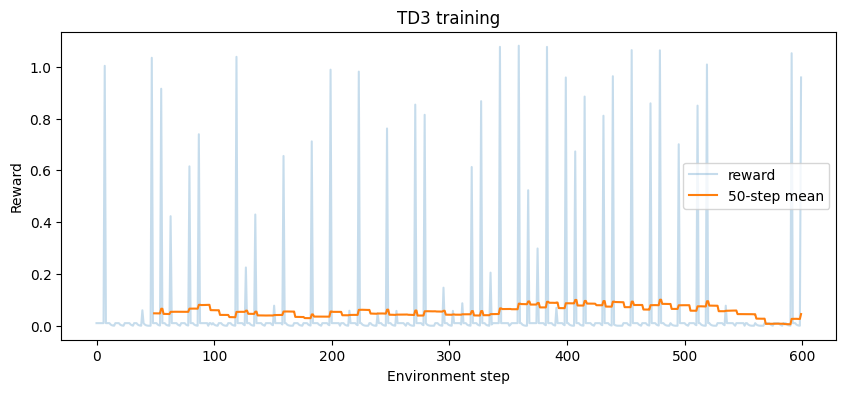

/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,playable,rdiff,rmono,total_reward,totaldmg,damage_std
count,75.000000,75.000000,75.000000,75.000000,75.000,75.000000
mean,0.626667,0.365453,0.413689,0.406822,inf,3.333333
std,0.486947,0.408769,0.341737,0.432463,NaN,6.121418
min,0.000000,0.000000,0.000000,0.000000,0.250,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.475,0.000000
50%,1.000000,0.089535,0.573333,0.146868,25.575,1.186381
75%,1.000000,0.795420,0.673333,0.856078,NaN,3.797339
max,1.000000,0.999175,0.946667,1.081044,inf,32.707606


In [26]:

window = 50
smooth = pd.Series(reward_history).rolling(window).mean()

plt.figure(figsize=(10,4))
plt.plot(reward_history, alpha=0.25, label="reward")
plt.plot(smooth, label=f"{window}-step mean")
plt.xlabel("Environment step")
plt.ylabel("Reward")
plt.title("TD3 training")
plt.legend()
plt.show()

if final_scores:
    df_scores = pd.DataFrame(final_scores)
    display(df_scores.describe())



{'playable': 1, 'rdiff': 0.4492784174520616, 'rmono': 0.47333333333333333, 'total_reward': 0.49661175078539493, 'totaldmg': 18.12, 'damage_std': 3.424850361694654}


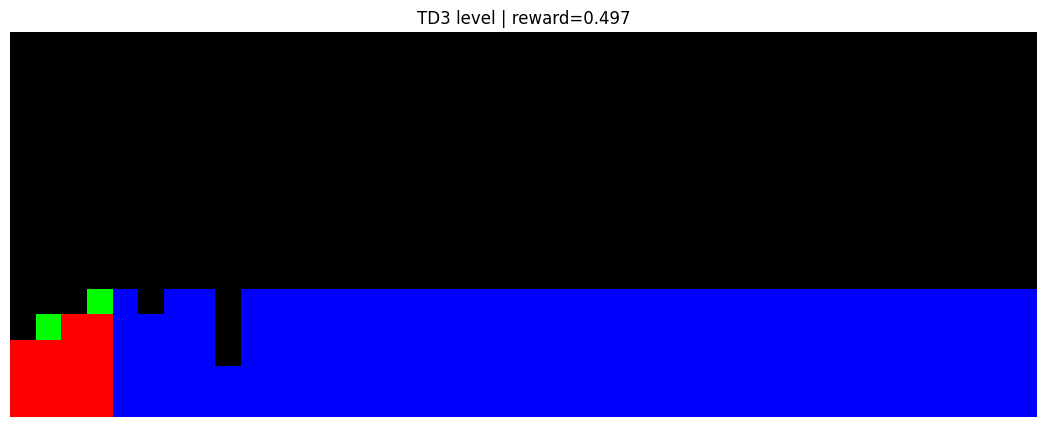

In [27]:

@torch.no_grad()
def generate_td3_level(agent, random_init_count=2, noise_std=0.0, seed=123):
    patterns = random_initial_patterns(random_init_count, seed=seed)

    while len(patterns) < MAX_LEVEL_PATTERNS:
        state = state_from_patterns(patterns)
        action = agent.act(state, noise_std=noise_std)
        p = generate_pattern_from_action(action, patterns)
        patterns.append(p)

    return patterns

td3_level = generate_td3_level(agent, random_init_count=2, noise_std=0.0)
td3_score = evaluate_level(td3_level, difficulty_trials=10, seed=123)

print(td3_score)
show_level(td3_level, f"TD3 level | reward={td3_score['total_reward']:.3f}")



In [28]:

def ri_experiment(agent, counts=range(1,9), levels_per_count=20):
    rows = []

    for c in counts:
        for i in tqdm(range(levels_per_count), desc=f"RI c={c}", leave=False):
            lvl = generate_td3_level(
                agent,
                random_init_count=c,
                noise_std=0.0,
                seed=10000 + c*100 + i
            )
            score = evaluate_level(lvl, difficulty_trials=4, seed=i)
            rows.append({
                "c": c,
                **score
            })

    return pd.DataFrame(rows)

ri_df = ri_experiment(agent, levels_per_count=10)
display(ri_df.groupby("c")[["total_reward","rdiff","rmono","totaldmg"]].mean())



RI c=1:   0%|          | 0/10 [00:00<?, ?it/s]

RI c=2:   0%|          | 0/10 [00:00<?, ?it/s]

RI c=3:   0%|          | 0/10 [00:00<?, ?it/s]

RI c=4:   0%|          | 0/10 [00:00<?, ?it/s]

RI c=5:   0%|          | 0/10 [00:00<?, ?it/s]

RI c=6:   0%|          | 0/10 [00:00<?, ?it/s]

RI c=7:   0%|          | 0/10 [00:00<?, ?it/s]

RI c=8:   0%|          | 0/10 [00:00<?, ?it/s]

,total_reward,rdiff,rmono,totaldmg
c,,,,
1,0.215133,0.178533,0.366000,inf
2,0.414848,0.373848,0.410000,inf
3,0.346265,0.302198,0.440667,inf
4,0.585894,0.523161,0.627333,inf
5,0.695107,0.615507,0.796000,inf
6,0.422514,0.358181,0.643333,inf
7,0.618135,0.533335,0.848000,inf
8,0.254319,0.194319,0.600000,inf


In [29]:

def tile_difference(level_a, level_b):
    a = level_grid(level_a)
    b = level_grid(level_b)
    return int(np.sum(a != b))


def kl_divergence_discrete(a, b, eps=1e-8):
    def encode(level):
        wall, enemy, hole = level
        x = np.zeros_like(wall, dtype=np.int32)
        x[wall > 0.5] = 2
        x[enemy > 0.5] = 3
        return x

    x = encode(a).flatten()
    y = encode(b).flatten()

    vals = [0,2,3]
    px = np.array([(x == v).mean() for v in vals]) + eps
    py = np.array([(y == v).mean() for v in vals]) + eps

    px = px / px.sum()
    py = py / py.sum()

    return float(np.sum(px * np.log(px / py)))


def diversity_metrics(levels):
    rows = []
    for i in range(len(levels)):
        for j in range(i+1, len(levels)):
            rows.append({
                "i": i,
                "j": j,
                "different_tiles": tile_difference(levels[i], levels[j]),
                "KLlevel": kl_divergence_discrete(levels[i], levels[j])
            })
    return pd.DataFrame(rows)


{'playable': 1, 'rdiff': 0.4492784174520616, 'rmono': 0.47333333333333333, 'total_reward': 0.49661175078539493, 'totaldmg': 18.12, 'damage_std': 3.424850361694654}


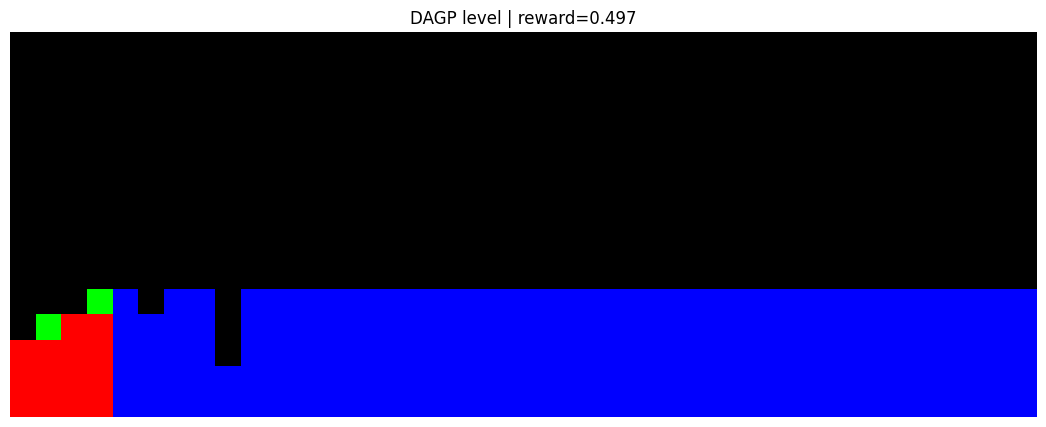

In [30]:

@torch.no_grad()
def q_value(agent, state, action):
    s = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    a = torch.tensor(action, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    q1 = agent.critic1(s,a).item()
    q2 = agent.critic2(s,a).item()
    return min(q1, q2)


def pattern_kl_distance(a, b, eps=1e-8):
    def dist(p):
        wall, enemy, hole = p
        x = np.zeros_like(wall, dtype=np.int32)
        x[wall > 0.5] = 2
        x[enemy > 0.5] = 3
        vals = [0,2,3]
        d = np.array([(x == v).mean() for v in vals], dtype=np.float64) + eps
        return d / d.sum()

    p = dist(a)
    q = dist(b)
    return float(np.sum(p * np.log(p/q)))


def dagp_choose(agent, patterns, n_candidates=20, distance_threshold=0.10, seed=0):
    state = state_from_patterns(patterns)

    best_action = agent.act(state, noise_std=0.0)
    best_pattern = generate_pattern_from_action(best_action, patterns)

    candidates = []
    rng = np.random.default_rng(seed)

    for _ in range(n_candidates):
        action = rng.random(3).astype(np.float32)
        pattern = generate_pattern_from_action(action, patterns)
        dist = pattern_kl_distance(pattern, best_pattern)

        if dist >= distance_threshold:
            q = q_value(agent, state, action)
            candidates.append((q, action, pattern, dist))

    if not candidates:
        return best_action, best_pattern, 0.0, "greedy"

    candidates.sort(key=lambda x: x[0], reverse=True)
    q, action, pattern, dist = candidates[0]
    return action, pattern, dist, "DAGP"


def generate_dagp_level(
    agent,
    random_init_count=2,
    noise_positions=(2,3,4),
    n_candidates=20,
    threshold=0.10,
    seed=123
):
    patterns = random_initial_patterns(random_init_count, seed=seed)
    step = len(patterns)

    while len(patterns) < MAX_LEVEL_PATTERNS:
        if step in noise_positions:
            _, p, dist, mode = dagp_choose(
                agent,
                patterns,
                n_candidates=n_candidates,
                distance_threshold=threshold,
                seed=seed+step
            )
        else:
            state = state_from_patterns(patterns)
            action = agent.act(state, noise_std=0.0)
            p = generate_pattern_from_action(action, patterns)

        patterns.append(p)
        step += 1

    return patterns


dagp_level = generate_dagp_level(
    agent,
    random_init_count=2,
    n_candidates=20,
    threshold=0.10
)

dagp_score = evaluate_level(dagp_level, difficulty_trials=10, seed=123)
print(dagp_score)
show_level(dagp_level, f"DAGP level | reward={dagp_score['total_reward']:.3f}")



In [37]:

N_EVAL = 30

random_levels = [
    generate_level_random(10, seed=5000+i)
    for i in range(N_EVAL)
]

rl_ri_levels = [
    generate_td3_level(agent, random_init_count=2, noise_std=0.0, seed=6000+i)
    for i in range(N_EVAL)
]

rl_dagp_levels = [
    generate_dagp_level(
        agent,
        random_init_count=2,
        n_candidates=20,
        threshold=0.10,
        seed=7000+i
    )
    for i in range(N_EVAL)
]

def summarize_set(name, levels):
    scores = [evaluate_level(lvl, difficulty_trials=5, seed=i) for i,lvl in enumerate(levels)]
    df = pd.DataFrame(scores)
    df["method"] = name
    return df, scores

random_df, random_scores = summarize_set("Random", random_levels)
ri_df2, ri_scores = summarize_set("RL-RI", rl_ri_levels)
dagp_df, dagp_scores = summarize_set("RL-RI+DAGP", rl_dagp_levels)

quality_df = pd.concat([random_df, ri_df2, dagp_df], ignore_index=True)

display(
    quality_df.groupby("method")[
        ["playable","rdiff","rmono","total_reward","totaldmg"]
    ].agg(["mean","std"])
)



playable               rdiff               rmono            \
                mean       std      mean       std      mean       std   
method                                                                   
RL-RI       0.766667  0.430183  0.354411  0.378355  0.454444  0.291836   
RL-RI+DAGP  0.800000  0.406838  0.438623  0.411450  0.481778  0.278347   
Random      0.833333  0.379049  0.369770  0.303200  0.833333  0.379049   

           total_reward           totaldmg      
                   mean       std     mean std  
method                                          
RL-RI          0.399856  0.394681      inf NaN  
RL-RI+DAGP     0.486801  0.431742      inf NaN  
Random         0.453103  0.325757      inf NaN

In [41]:
def diversity_metrics(levels):
    """
    Calculate pairwise diversity between individual levels.

    Accepts:
        (N, 3, H, W)
    or
        (N, M, 3, H, W)

    The second form is flattened into:
        (N*M, 3, H, W)
    """

    levels = np.asarray(levels)

    print("Original diversity input shape:", levels.shape)

    # ------------------------------------------------
    # Case 1:
    # (N, M, 3, H, W)
    # ------------------------------------------------
    if levels.ndim == 5:

        n_groups, n_levels, channels, height, width = levels.shape

        if channels != 3:
            raise ValueError(
                f"Expected 3 channels, got {channels}"
            )

        # Flatten groups and levels
        levels = levels.reshape(
            n_groups * n_levels,
            channels,
            height,
            width
        )

        print(
            "Flattened diversity shape:",
            levels.shape
        )

    # ------------------------------------------------
    # Case 2:
    # (N, 3, H, W)
    # ------------------------------------------------
    elif levels.ndim == 4:

        if levels.shape[1] != 3:
            raise ValueError(
                f"Expected 3 channels, got {levels.shape[1]}"
            )

    else:
        raise ValueError(
            f"Unexpected level shape: {levels.shape}"
        )

    different_tiles = []
    KLlevel = []

    # ------------------------------------------------
    # Compare every pair of levels
    # ------------------------------------------------

    for i in range(len(levels)):

        for j in range(i + 1, len(levels)):

            level_a = levels[i]
            level_b = levels[j]

            # Make sure both are (3,H,W)
            a = _normalize_level_shape(level_a)
            b = _normalize_level_shape(level_b)

            # ----------------------------------------
            # Convert to tile IDs
            # ----------------------------------------

            def encode_tiles(level):

                wall, enemy, hole = level

                tile_map = np.zeros_like(
                    wall,
                    dtype=np.int32
                )

                # Empty = 0
                # Hole = 1
                # Wall = 2
                # Enemy = 3

                tile_map[hole > 0.5] = 1
                tile_map[wall > 0.5] = 2
                tile_map[enemy > 0.5] = 3

                return tile_map

            tiles_a = encode_tiles(a)
            tiles_b = encode_tiles(b)

            # ----------------------------------------
            # Different tile ratio
            # ----------------------------------------

            different_ratio = np.mean(
                tiles_a != tiles_b
            )

            different_tiles.append(
                different_ratio
            )

            # ----------------------------------------
            # KL divergence
            # ----------------------------------------

            kl = kl_divergence_discrete(
                level_a,
                level_b
            )

            KLlevel.append(kl)

    return {
        "different_tiles": np.asarray(
            different_tiles,
            dtype=np.float64
        ),

        "KLlevel": np.asarray(
            KLlevel,
            dtype=np.float64
        )
    }

In [42]:
def pairwise_diversity_summary(levels, name):

    dm = diversity_metrics(levels)

    return {
        "method": name,
        "different_tiles_mean": dm["different_tiles"].mean(),
        "different_tiles_std": dm["different_tiles"].std(),
        "KLlevel_mean": dm["KLlevel"].mean(),
        "KLlevel_std": dm["KLlevel"].std()
    }


div_summary = pd.DataFrame([

    pairwise_diversity_summary(
        random_levels,
        "Random"
    ),

    pairwise_diversity_summary(
        rl_ri_levels,
        "RL-RI"
    ),

    pairwise_diversity_summary(
        rl_dagp_levels,
        "RL-RI+DAGP"
    )
])

display(div_summary)

Original diversity input shape: (30, 10, 3, 15, 4)
Flattened diversity shape: (300, 3, 15, 4)
Original diversity input shape: (30, 10, 3, 15, 4)
Flattened diversity shape: (300, 3, 15, 4)
Original diversity input shape: (30, 10, 3, 15, 4)
Flattened diversity shape: (300, 3, 15, 4)


,method,different_tiles_mean,different_tiles_std,KLlevel_mean,KLlevel_std
0,Random,0.280349,0.117824,1.401477,1.740322
1,RL-RI,0.240479,0.142694,1.520783,1.847094
2,RL-RI+DAGP,0.243162,0.136352,1.533957,1.801538


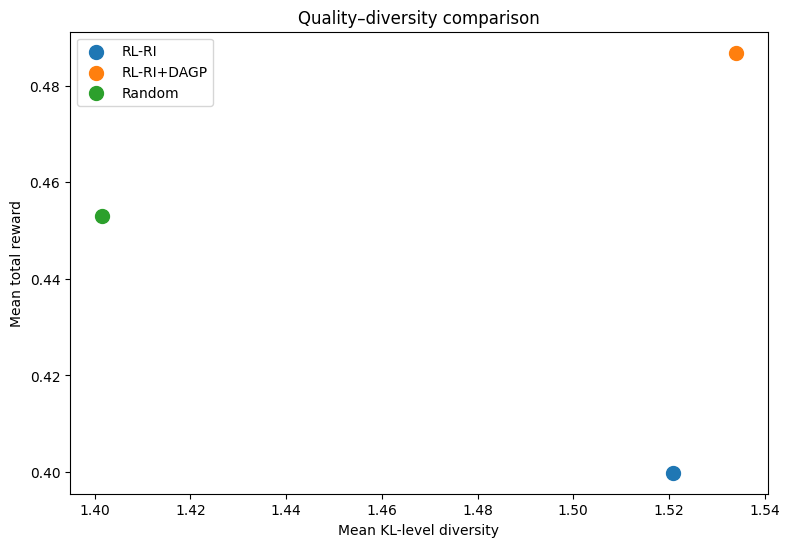

In [43]:
fig, ax = plt.subplots(figsize=(9,6))

for method, group in quality_df.groupby("method"):
    x = div_summary.loc[div_summary.method == method, "KLlevel_mean"].iloc[0]
    y = group["total_reward"].mean()
    ax.scatter(x, y, s=100, label=method)

ax.set_xlabel("Mean KL-level diversity")
ax.set_ylabel("Mean total reward")
ax.set_title("Quality–diversity comparison")
ax.legend()
plt.show()

In [44]:

RUN_VS = False

if RUN_VS:
    vs_agent, vs_replay, vs_rewards, vs_scores = train_td3(
        episodes=20,
        use_vs=True,
        vs_samples=2,
        random_init_count=2,
        warmup=128
    )
    print("VS training completed:", len(vs_rewards), "steps")
else:
    print("RUN_VS=False — VS training skipped.")



RUN_VS=False — VS training skipped.


,method,level_id,playable,rdiff,rmono,total_reward,totaldmg,damage_std
0,td3_ri,0,0,0.000000e+00,0.000000,0.000000,inf,0.000000
1,td3_ri,1,1,8.228121e-02,0.573333,0.139615,25.88,16.375702
2,td3_ri,2,1,7.041928e-01,0.373333,0.741526,1.30,0.900000
3,td3_ri,3,1,3.375743e-01,0.473333,0.384908,19.79,9.420345
4,td3_ri,4,0,0.000000e+00,0.000000,0.000000,inf,0.000000
5,td3_dagp,0,1,8.029578e-01,0.673333,0.870291,2.70,1.268858
6,td3_dagp,1,1,7.377133e-01,0.473333,0.785047,1.76,1.174904
7,td3_dagp,2,1,8.482376e-01,0.773333,0.925571,3.41,3.793007
8,td3_dagp,3,1,7.874832e-01,0.573333,0.844817,13.53,4.770755
9,td3_dagp,4,1,1.835706e-23,0.273333,0.027333,89.86,29.799403


Saved results to: mario_pcgrl_project/outputs/final_results.csv


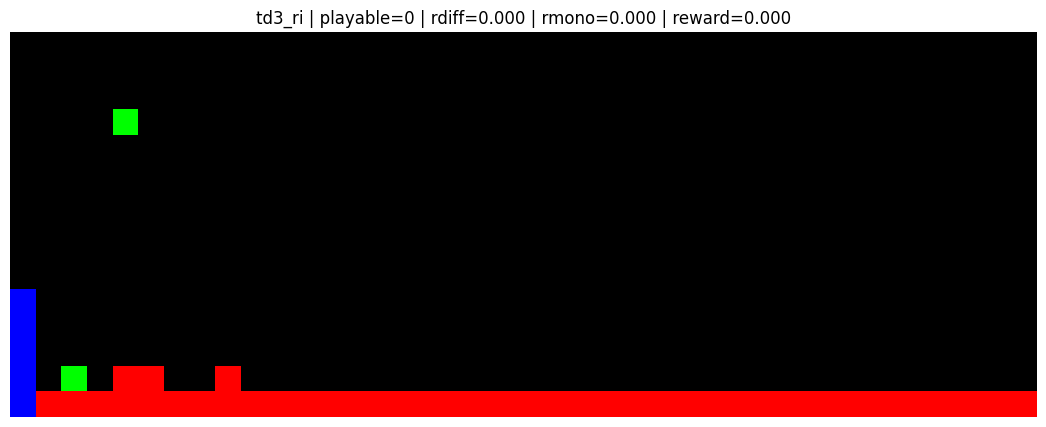

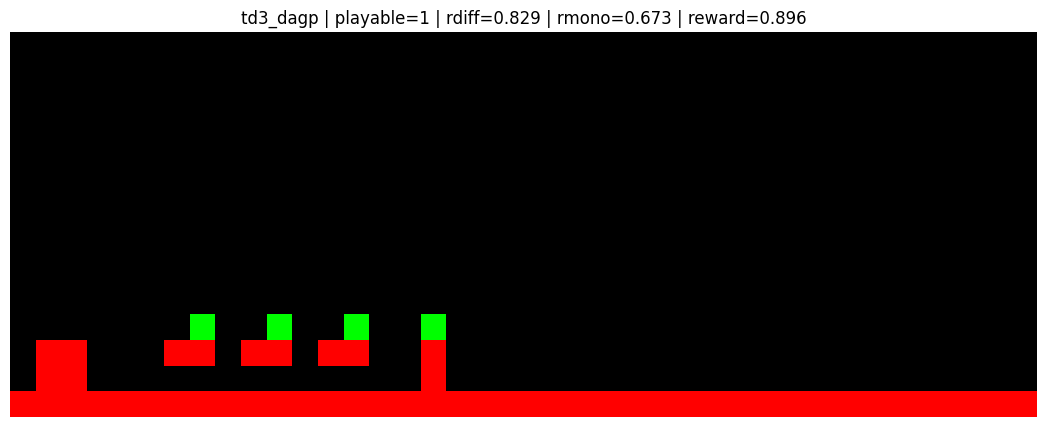

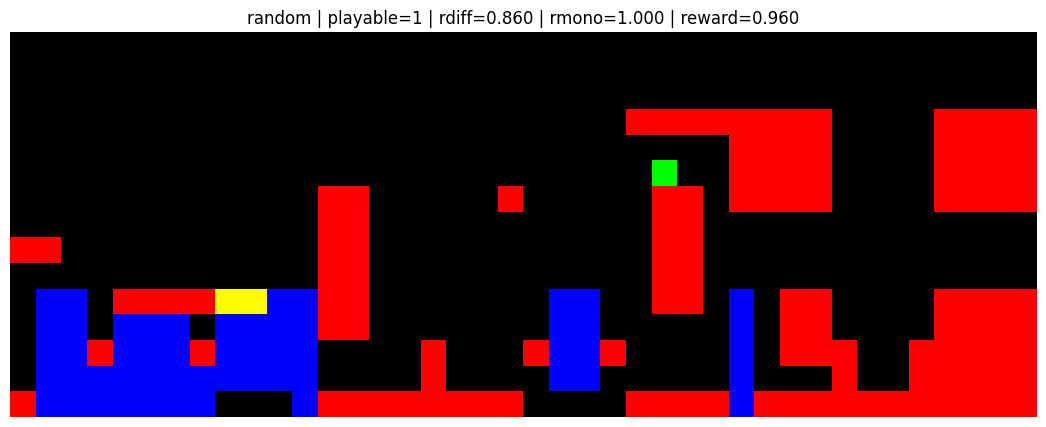

Saved: mario_pcgrl_project/outputs/cgan.pt
Saved: mario_pcgrl_project/outputs/td3.pt


In [48]:

OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

final_levels = {
    "td3_ri": rl_ri_levels[:5],
    "td3_dagp": rl_dagp_levels[:5],
    "random": random_levels[:5],
}

records = []

for method, levels in final_levels.items():
    for i, lvl in enumerate(levels):
        score = evaluate_level(lvl, difficulty_trials=10, seed=9000+i)
        records.append({
            "method": method,
            "level_id": i,
            **score
        })

        np.save(OUTPUT_DIR / f"{method}_{i}.npy", level_grid(lvl))

results_csv = OUTPUT_DIR / "final_results.csv"
final_df = pd.DataFrame(records)
final_df.to_csv(results_csv, index=False)

display(final_df)
print("Saved results to:", results_csv)



for method, levels in final_levels.items():
    lvl = levels[0]
    score = evaluate_level(lvl, difficulty_trials=10, seed=999)
    show_level(
        lvl,
        f"{method} | playable={score['playable']} | "
        f"rdiff={score['rdiff']:.3f} | "
        f"rmono={score['rmono']:.3f} | "
        f"reward={score['total_reward']:.3f}"
    )


# %% [markdown]
## 10. Save trained models



torch.save({
    "generator": G.state_dict(),
    "discriminator": D.state_dict()
}, OUTPUT_DIR / "cgan.pt")

torch.save({
    "actor": agent.actor.state_dict(),
    "actor_target": agent.actor_target.state_dict(),
    "critic1": agent.critic1.state_dict(),
    "critic2": agent.critic2.state_dict(),
    "critic1_target": agent.critic1_target.state_dict(),
    "critic2_target": agent.critic2_target.state_dict(),
}, OUTPUT_DIR / "td3.pt")

print("Saved:", OUTPUT_DIR / "cgan.pt")
print("Saved:", OUTPUT_DIR / "td3.pt")

